<a href="https://colab.research.google.com/github/ivan-penta/proyecto_cidam/blob/main/proyecto_cidam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Creción del ámbiente en PySpark

In [1]:
# 1. Instalar Java 17 y PySpark
!apt-get update -qq
!apt-get install openjdk-17-jdk -y
!pip install pyspark==4.0.1 -q

# 2. Configurar variables de entorno
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

# 3. Verificar instalación de Java
!java -version

# 4. Crear SparkSession
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Analisis Compranet Big Data") \
    .master("local[*]") \
    .config("spark.driver.memory", "8g") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.driver.maxResultSize", "4g") \
    .getOrCreate()

print("✅ SparkSession creada")
print("Versión:", spark.version)
print("App Name:", spark.sparkContext.appName)
print("Master:", spark.sparkContext.master)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
openjdk-17-jdk is already the newest version (17.0.18+8-1~22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 8 not upgraded.
openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
✅ SparkSession creada
Versión: 4.0.1
App Name: Analisis Compranet Big Data
Master: local[*]


### Cargar dataset

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, expr

spark = SparkSession.builder \
    .appName("Analisis Compranet Big Data") \
    .getOrCreate()

print("📂 Cargando dataset completo de CompraNet...")


data = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .option("multiLine", "true") \
    .option("escape", "\"") \
    .csv("compranet_historico.csv")

data = data.withColumn(
    "importe",
    expr("try_cast(importe as double)")
)

conteo_nulos = data.filter(col("importe").isNull()).count()
print(f"⚠️ Registros con formato inválido convertidos a NULL: {conteo_nulos}")

total_registros = data.count()
print(f"📊 Total de registros procesados: {total_registros:,}")

data.write.mode("overwrite").parquet("compranet_historico.parquet")
print("💾 Dataset completo guardado exitosamente en formato Parquet.")

📂 Cargando dataset completo de CompraNet...
⚠️ Registros con formato inválido convertidos a NULL: 5188
📊 Total de registros procesados: 2,356,612
💾 Dataset completo guardado exitosamente en formato Parquet.


In [3]:
from pyspark.sql.functions import col

registros_antes=data.count()

data = data.dropna(subset=[
    "importe","ff_fecha_inicio",
    "ff_fecha_fin"
])

registros_despues = data.count()

print(f"Registros antes de limpieza: {registros_antes}")
print(f"Registros después de limpieza: {registros_despues}")
print(f"Número de registros eliminados: {registros_antes - registros_despues}")

Registros antes de limpieza: 2356612
Registros después de limpieza: 2347566
Número de registros eliminados: 9046


In [4]:
num_registros =data.count()
num_columnas = len(data.columns)

print(f"Número de registros: {num_registros}")
print(f"Número de columnas: {num_columnas}")

Número de registros: 2347566
Número de columnas: 16


### Selección de variables relevantes

In [5]:
from pyspark.sql.functions import col

df = data.select(
    "codigo_contrato",
    "codigo_expediente",
    "proveedor",
    "contract_type",
    "tipo_contratacion",
    "tipo_expediente",
    "importe",
    "moneda",
    "fecha_inicio",
    "fecha_fin"
)

df.show(5)

+---------------+-----------------+--------------------+---------------+--------------------+--------------------+----------+------+--------------------+--------------------+
|codigo_contrato|codigo_expediente|           proveedor|  contract_type|   tipo_contratacion|     tipo_expediente|   importe|moneda|        fecha_inicio|           fecha_fin|
+---------------+-----------------+--------------------+---------------+--------------------+--------------------+----------+------+--------------------+--------------------+
|        2376191|          2161394|Equity Appraisal ...|    3.Servicios|           Servicios|05. Adjudicación ...|   89012.0|   MXN|2020-07-22 05:00:...|2020-08-27 04:59:...|
|             89|              348|Si Vale Mexico Sa...|ADQUISICIONES_0|No especificado p...|V20151220 12. Adj...| 5980292.7|   MXN|2010-12-06 06:00:...|2011-01-01 05:59:...|
|           1756|              399|Metlife Mexico Sa...|    SERVICIOS_1|No especificado p...|V20110525 01. Lic...| 3904647.0|

### Converción de fechas

In [6]:
from pyspark.sql.functions import to_timestamp, col

df = df.withColumn(
    "fecha_inicio",
    to_timestamp(col("fecha_inicio"))
)

df = df.withColumn(
    "fecha_fin",
    to_timestamp(col("fecha_fin"))
)

In [7]:
df = df.filter(col("fecha_inicio").isNotNull())

#### Crear variable año

In [8]:
from pyspark.sql.functions import year

df = df.withColumn(
    "anio",
    year(col("fecha_inicio"))
)

df.select("fecha_inicio","anio").show(5)

+-------------------+----+
|       fecha_inicio|anio|
+-------------------+----+
|2020-07-22 05:00:00|2020|
|2010-12-06 06:00:00|2010|
|2011-01-01 06:00:00|2011|
|2011-01-01 06:00:00|2011|
|2011-01-01 06:00:00|2011|
+-------------------+----+
only showing top 5 rows


### Seleccionar periodo de estudio

In [9]:
from pyspark.sql.functions import to_date, lit

df = df.filter(
    (col("fecha_inicio") >= to_date(lit("2012-12-01"))) &
    (col("fecha_inicio") <= to_date(lit("2024-11-30")))
).filter(col("fecha_inicio").isNotNull())

print(f"Registros en periodo: {df.count():,}")

Registros en periodo: 2,052,702


### Variable sexenio

In [10]:
from pyspark.sql.functions import col, lit, when, to_timestamp

df = df.withColumn(
    "sexenio",
    when(
        (col("fecha_inicio") >= to_timestamp(lit("2012-12-01 00:00:00"))) &
        (col("fecha_inicio") < to_timestamp(lit("2018-12-01 00:00:00"))),
        "EPN"
    ).when(
        (col("fecha_inicio") >= to_timestamp(lit("2018-12-01 00:00:00"))) &
        (col("fecha_inicio") < to_timestamp(lit("2024-12-01 00:00:00"))),
        "AMLO"
    )
)

### Contratos por sexenio

In [11]:
contratos_sexenio = df.groupBy("sexenio").count()

contratos_sexenio.show()

+-------+-------+
|sexenio|  count|
+-------+-------+
|    EPN|1270084|
|   AMLO| 782618|
+-------+-------+



### Importes por inflación

In [12]:
# INPC base 2018 (datos Banxico, índice promedio anual)
inpc = {
    2012: 47.23, 2013: 49.04, 2014: 51.10,
    2015: 52.36, 2016: 54.53, 2017: 57.71,
    2018: 61.20,  # año base
    2019: 65.28, 2020: 68.01, 2021: 72.58,
    2022: 80.95, 2023: 87.62, 2024: 92.10
}

from pyspark.sql.functions import create_map, lit
from itertools import chain

# Crear mapa de INPC en Spark
inpc_map = create_map([lit(x) for x in chain(*inpc.items())])

INPC_BASE = 61.20  # 2018

df = df.withColumn(
    "inpc_anio",
    inpc_map[col("anio")]
).withColumn(
    "importe_real",
    col("importe") * lit(INPC_BASE) / col("inpc_anio")
)

### Monto total por sexenio

In [13]:
from pyspark.sql.functions import sum, format_number

monto_sexenio = df.groupBy("sexenio").agg(
    sum("importe_real").alias("monto_total")
)

monto_sexenio = monto_sexenio.withColumn(
    "monto_total",
    format_number("monto_total", 2)
)

monto_sexenio.select("sexenio", "monto_total").show(truncate=False)

+-------+--------------------+
|sexenio|monto_total         |
+-------+--------------------+
|EPN    |3,222,897,523,224.10|
|AMLO   |1,938,538,504,416.51|
+-------+--------------------+



### Importe promedio por contrato

In [14]:
from pyspark.sql.functions import avg
prom_sexenio = df.groupBy("sexenio").agg(
    avg("importe_real").alias("importe_promedio"))

prom_sexenio = prom_sexenio.withColumn(
    "importe_promedio",
    format_number("importe_promedio", 2)
)

prom_sexenio.select("sexenio", "importe_promedio").show(truncate=False)

+-------+----------------+
|sexenio|importe_promedio|
+-------+----------------+
|EPN    |2,537,546.75    |
|AMLO   |2,476,991.97    |
+-------+----------------+



### Modalidades de contratación por sexenio

In [15]:
modalidades = df.groupBy(
    "sexenio",
    "tipo_contratacion"
).count()

modalidades.orderBy("sexenio").show(50)

+-------+--------------------+------+
|sexenio|   tipo_contratacion| count|
+-------+--------------------+------+
|   AMLO|       Adquisiciones|478476|
|   AMLO|      Arrendamientos|  4409|
|   AMLO|Servicios Relacio...|  9526|
|   AMLO|        Obra Pública| 35050|
|   AMLO|            Sin dato| 13096|
|   AMLO|           Servicios|242061|
|    EPN|            Sin dato|  3053|
|    EPN|       Adquisiciones|647848|
|    EPN|           Servicios|440442|
|    EPN|        Obra Pública|143863|
|    EPN|      Arrendamientos|  7953|
|    EPN|Servicios Relacio...| 26888|
|    EPN|No especificado p...|    37|
+-------+--------------------+------+



### Porcentaje de cada modalidad

In [16]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import count

total_sexenio = df.groupBy("sexenio").agg(count("*").alias("count"))

total_sexenio = total_sexenio.withColumnRenamed("count", "total_count")
from pyspark.sql.functions import round

modalidades_pct = modalidades.join(total_sexenio, "sexenio") \
    .withColumn(
        "porcentaje",
        round(col("count") / col("total_count") * 100, 2)
    )

modalidades_pct.show()

+-------+--------------------+------+-----------+----------+
|sexenio|   tipo_contratacion| count|total_count|porcentaje|
+-------+--------------------+------+-----------+----------+
|    EPN|No especificado p...|    37|    1270084|       0.0|
|    EPN|Servicios Relacio...| 26888|    1270084|      2.12|
|    EPN|      Arrendamientos|  7953|    1270084|      0.63|
|    EPN|        Obra Pública|143863|    1270084|     11.33|
|    EPN|           Servicios|440442|    1270084|     34.68|
|    EPN|       Adquisiciones|647848|    1270084|     51.01|
|    EPN|            Sin dato|  3053|    1270084|      0.24|
|   AMLO|           Servicios|242061|     782618|     30.93|
|   AMLO|            Sin dato| 13096|     782618|      1.67|
|   AMLO|        Obra Pública| 35050|     782618|      4.48|
|   AMLO|Servicios Relacio...|  9526|     782618|      1.22|
|   AMLO|      Arrendamientos|  4409|     782618|      0.56|
|   AMLO|       Adquisiciones|478476|     782618|     61.14|
+-------+---------------

### Proveedores por sexenio

In [17]:
from pyspark.sql.functions import sum, col, format_number

# Agrupar por sexenio y proveedor, sumando el importe
proveedores_monto = df.groupBy("sexenio", "proveedor").agg(
    sum("importe_real").alias("monto_total")
)

proveedores_monto.orderBy(col("monto_total").desc()).select(
    "sexenio",
    "proveedor",
    format_number(col("monto_total"), 2).alias("monto")
).show(20, truncate=False)

+-------+--------------------------------------------------------------------+------------------+
|sexenio|proveedor                                                           |monto             |
+-------+--------------------------------------------------------------------+------------------+
|EPN    |Grupo Farmacos Especializados Sa de Cv                              |101,996,685,668.28|
|EPN    |Operadora Cicsa, S.A. de C.V.                                       |98,225,098,328.72 |
|AMLO   |Electromecanica de Montacargas Sa de Cv                             |60,521,056,820.95 |
|EPN    |Farmaceuticos Maypo, S.A. de C.V.                                   |46,855,505,275.91 |
|AMLO   |Toka Internacional S a P I de Cv                                    |44,289,797,258.02 |
|EPN    |Distribuidora Internacional de Medicamentos y Equipo Medico Sa de Cv|40,358,798,115.40 |
|EPN    |Cic Corporativo Industrial Coahuila Sa de Cv                        |29,624,593,800.98 |
|EPN    |Grupo Const

### Top proveedores por sexenio

In [18]:
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, col, format_number

window = Window.partitionBy("sexenio").orderBy(col("monto_total").desc())

top_prov = proveedores_monto.withColumn(
    "rank",
    row_number().over(window)
)

top_prov.filter(col("rank") <= 10).select(
    "sexenio",
    "proveedor",
    format_number(col("monto_total"), 2).alias("monto_total"),
    "rank"
).show(truncate=False)

+-------+--------------------------------------------------------------------+------------------+----+
|sexenio|proveedor                                                           |monto_total       |rank|
+-------+--------------------------------------------------------------------+------------------+----+
|AMLO   |Electromecanica de Montacargas Sa de Cv                             |60,521,056,820.95 |1   |
|AMLO   |Toka Internacional S a P I de Cv                                    |44,289,797,258.02 |2   |
|AMLO   |Alstom Transport Mexico Sa de Cv                                    |26,578,286,394.23 |3   |
|AMLO   |Ica Constructora Sa de Cv                                           |24,898,628,876.81 |4   |
|AMLO   |Currie & Brown - Mexico Sa de Cv                                    |21,745,478,093.14 |5   |
|AMLO   |Farmaceuticos Maypo, S.A. de C.V.                                   |20,606,706,537.66 |6   |
|AMLO   |Laboratorios de Biologicos y Reactivos de Mexico Sa de Cv       

### Duración promedio de contratos

In [19]:
from pyspark.sql.functions import datediff

df = df.withColumn(
    "duración_días",
    datediff(col("fecha_fin"), col("fecha_inicio")
))

dura_sexenio = df.groupBy("sexenio").agg(
    round(avg("duración_días"), 2).alias("duración_promedio")
)

dura_sexenio.show()

+-------+-----------------+
|sexenio|duración_promedio|
+-------+-----------------+
|    EPN|           111.29|
|   AMLO|           122.62|
+-------+-----------------+



### Evolución de contratos por año

In [20]:
contrato_anio = df.groupBy("sexenio","anio").count().orderBy("anio")

contrato_anio.show()

+-------+----+------+
|sexenio|anio| count|
+-------+----+------+
|    EPN|2012|  9714|
|    EPN|2013|181812|
|    EPN|2014|197294|
|    EPN|2015|222760|
|    EPN|2016|233587|
|    EPN|2017|234168|
|    EPN|2018|190749|
|   AMLO|2018|  7341|
|   AMLO|2019|193798|
|   AMLO|2020|162073|
|   AMLO|2021|203393|
|   AMLO|2022|197385|
|   AMLO|2023| 16798|
|   AMLO|2024|  1830|
+-------+----+------+



### Evolución del gasto público

In [21]:
from pyspark.sql.functions import sum, col, format_number

monto_anio = df.groupBy("sexenio", "anio").agg(
    sum("importe_real").alias("monto_total")
).orderBy("anio")

monto_anio.select(
    "sexenio",
    "anio",
    format_number(col("monto_total"), 2).alias("monto total")
).show(truncate=False)

+-------+----+------------------+
|sexenio|anio|monto total       |
+-------+----+------------------+
|EPN    |2012|28,926,488,815.28 |
|EPN    |2013|483,141,446,902.53|
|EPN    |2014|644,888,100,743.10|
|EPN    |2015|524,765,818,022.90|
|EPN    |2016|505,875,006,338.52|
|EPN    |2017|603,618,598,648.07|
|EPN    |2018|431,682,063,753.26|
|AMLO   |2018|14,926,944,984.30 |
|AMLO   |2019|384,757,519,902.79|
|AMLO   |2020|455,635,059,912.59|
|AMLO   |2021|433,789,717,658.29|
|AMLO   |2022|429,536,617,273.79|
|AMLO   |2023|204,354,688,051.89|
|AMLO   |2024|15,537,956,632.86 |
+-------+----+------------------+



### Prueba estadística entre sexenios

In [22]:
from scipy.stats import ttest_ind

pdf =df.select("sexenio","importe").toPandas()

epn = pdf[pdf["sexenio"] == "EPN"]["importe"]
amlo = pdf[pdf["sexenio"] == "AMLO"]["importe"]

t_stat, p_value = ttest_ind(epn, amlo, equal_var=False)

print("t statistic:", t_stat)
print("p-value:", p_value)

t statistic: -4.941923674081993
p-value: 7.736425748046934e-07


### Machine Learning para diferencias sexenios

In [23]:
from pyspark.ml.feature import StringIndexer

indexer = StringIndexer(inputCol="sexenio", outputCol="sexenio_index")
df_ml = indexer.fit(df).transform(df)

### Variables del modelo

In [24]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["importe", "duración_días", "anio"],
    outputCol="features"
)

df_ml = assembler.transform(df_ml)

### Preparar features

In [25]:
from pyspark.sql.functions import log1p, col, month, dayofweek

df_ml = df.withColumn("log_importe", log1p(col("importe"))) \
          .withColumn("mes_inicio",  month(col("fecha_inicio"))) \
          .withColumn("dia_semana",  dayofweek(col("fecha_inicio")))

print("Columnas en df_ml:", df_ml.columns)
print("Nulos en log_importe:", df_ml.filter(col("log_importe").isNull()).count())

Columnas en df_ml: ['codigo_contrato', 'codigo_expediente', 'proveedor', 'contract_type', 'tipo_contratacion', 'tipo_expediente', 'importe', 'moneda', 'fecha_inicio', 'fecha_fin', 'anio', 'sexenio', 'inpc_anio', 'importe_real', 'duración_días', 'log_importe', 'mes_inicio', 'dia_semana']
Nulos en log_importe: 0


### VectorAssembler Sin año

In [26]:
assembler = VectorAssembler(
    inputCols=[
        "log_importe",
        "duración_días",
        "mes_inicio",
        "dia_semana",
        "tipo_ohe"
    ],
    outputCol = "features",
    handleInvalid = "skip"
)

### Pipeline

In [27]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline

cols_a_limpiar = ["label", "tipo_idx", "tipo_ohe", "features"]
for c in cols_a_limpiar:
    if c in df_ml.columns:
        df_ml = df_ml.drop(c)

indexer_sexenio = StringIndexer(
    inputCol="sexenio",
    outputCol="label"
)
indexer_tipo = StringIndexer(
    inputCol="tipo_contratacion",
    outputCol="tipo_idx",
    handleInvalid="keep"
)
encoder = OneHotEncoder(
    inputCols=["tipo_idx"],
    outputCols=["tipo_ohe"]
)
assembler = VectorAssembler(
    inputCols=["log_importe", "duración_días", "mes_inicio", "dia_semana", "tipo_ohe"],
    outputCol="features",
    handleInvalid="skip"
)

pipeline = Pipeline(stages=[indexer_sexenio, indexer_tipo, encoder, assembler])

pipeline_model = pipeline.fit(df_ml)
df_ml = pipeline_model.transform(df_ml)

print("Pipeline ejecutado correctamente")
df_ml.select("label", "tipo_ohe", "features").show(3, truncate=True)

Pipeline ejecutado correctamente
+-----+-------------+--------------------+
|label|     tipo_ohe|            features|
+-----+-------------+--------------------+
|  1.0|(7,[1],[1.0])|(11,[0,1,2,3,5],[...|
|  1.0|(7,[1],[1.0])|(11,[0,1,2,3,5],[...|
|  1.0|(7,[1],[1.0])|(11,[0,1,2,3,5],[...|
+-----+-------------+--------------------+
only showing top 3 rows


### Split temporal

In [28]:
from pyspark.sql.functions import col

train = df_ml.filter(
    ((col("sexenio")=="EPN") & (col("anio") <= 2016)) |
    ((col("sexenio")=="AMLO") & (col("anio") <= 2020))
)
test = df_ml.filter(
    ((col("sexenio")=="EPN") & (col("anio").isin([2017,2018]))) |
    ((col("sexenio")=="AMLO") & (col("anio").isin([2023,2024])))
)

print(f"Train: {train.count():,}  |  Test: {test.count():,}")

Train: 1,208,379  |  Test: 443,545


### Random Forest

In [29]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    numTrees=100,
    maxDepth=8,
    seed=42
)
model = rf.fit(train)
pred = model.transform(test)

### Evaluación

In [30]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

for metric in ["accuracy", "weightedPrecision", "weightedRecall", "f1"]:
    val = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName=metric
    ).evaluate(pred)
    print(f"{metric:20s}: {val:.4f}")

# Matriz de confusión

from pyspark.sql.functions import when

pred.withColumn(
    "sexenio_pred",
    when(col("prediction") == 0.0, "EPN").otherwise("AMLO")
).groupBy("sexenio", "sexenio_pred").count().orderBy("sexenio").show()

# Importancia de features

import pandas as pd

feature_names = (
    ["log_importe", "duración_días", "mes_inicio", "dia_semana"]
    + [f"tipo_ohe_{i}" for i in range(model.featureImportances.size -4)]
)
importances = pd.Series(
    model.featureImportances.toArray(),
    index=feature_names[:model.featureImportances.size]
).sort_values(ascending=False)
print("\nImportancia de features:")
print(importances.head(10))

accuracy            : 0.9582
weightedPrecision   : 0.9415
weightedRecall      : 0.9582
f1                  : 0.9391
+-------+------------+------+
|sexenio|sexenio_pred| count|
+-------+------------+------+
|   AMLO|        AMLO|   377|
|   AMLO|         EPN| 18251|
|    EPN|         EPN|424606|
|    EPN|        AMLO|   311|
+-------+------------+------+


Importancia de features:
duración_días    0.367579
tipo_ohe_2       0.248545
log_importe      0.086903
tipo_ohe_0       0.080190
mes_inicio       0.076450
dia_semana       0.074469
tipo_ohe_1       0.039915
tipo_ohe_3       0.022637
tipo_ohe_4       0.001668
tipo_ohe_5       0.001637
dtype: float64


## Índice de concentración de proveedores

### Gasto por proveedor y sexenio

In [31]:
from pyspark.sql.functions import sum, col, format_number

gasto_proveedor = df.groupBy(
    "sexenio",
    "proveedor"
).agg(
    sum("importe_real").alias("monto_proveedor")
).withColumn(
    "monto_proveedor", format_number(col("monto_proveedor"), 2)
)

gasto_proveedor.show(10)

+-------+--------------------+---------------+
|sexenio|           proveedor|monto_proveedor|
+-------+--------------------+---------------+
|   AMLO|Jose Manuel Amezc...|   1,470,638.08|
|    EPN|Basculas y Sistem...|      81,077.92|
|   AMLO|Zona Comercial Ri...|   3,361,617.64|
|    EPN|Servicio de Cpnte...|     337,458.60|
|    EPN|Desarrollos Casav...|  64,690,897.16|
|    EPN|  Margger Ingenieros|  13,209,725.90|
|    EPN|Comercializadora ...|  15,197,888.17|
|    EPN|Anvi delGolfo Sa ...|  40,010,133.65|
|    EPN|   Suplimex Sa de Cv| 220,564,736.82|
|    EPN|Proveedores Indus...| 223,690,443.84|
+-------+--------------------+---------------+
only showing top 10 rows


### Gasto total por sexenio

In [32]:
gasto_total_sexenio = df.groupBy(
    "sexenio"
).agg(
    sum("importe_real").alias("gasto_total")
).withColumn(
    "gasto_total", format_number(col("gasto_total"), 2)
)

gasto_total_sexenio.show()

+-------+--------------------+
|sexenio|         gasto_total|
+-------+--------------------+
|    EPN|3,222,897,523,224.10|
|   AMLO|1,938,538,504,416.51|
+-------+--------------------+



### Participación de mercado

In [33]:
from pyspark.sql.functions import sum, col

gasto_proveedor = df.groupBy("sexenio", "proveedor").agg(
    sum("importe_real").alias("monto_proveedor")
)

gasto_total_sexenio = df.groupBy("sexenio").agg(
    sum("importe_real").alias("gasto_total")
)

participacion = gasto_proveedor.alias("gp").join(
    gasto_total_sexenio.alias("gt"),
    col("gp.sexenio") == col("gt.sexenio")
).withColumn(
    "participacion",
    col("monto_proveedor") / col("gasto_total")
).select(
    col("gp.sexenio").alias("sexenio"),
    "proveedor",
    "monto_proveedor",
    "gasto_total",
    "participacion"
)

### Cálculo del HHI

In [34]:
from pyspark.sql.functions import pow

hhi = participacion.withColumn(
    "participacion_cuadrada",
    pow(col("participacion"),2)
)

hhi_sexenio = hhi.groupBy(
    "sexenio"
).agg(
    sum("participacion_cuadrada").alias("HHI")
)

hhi_sexenio.show()

+-------+--------------------+
|sexenio|                 HHI|
+-------+--------------------+
|    EPN| 0.00327336781673005|
|   AMLO|0.003591434082391263|
+-------+--------------------+



## Participación de adjudicación directa

### Variable unificada de tipo de contratación

In [35]:
df.select("tipo_expediente") \
  .distinct() \
  .orderBy("tipo_expediente") \
  .show(200, False)

+-------------------------------------------------------------------------------+
|tipo_expediente                                                                |
+-------------------------------------------------------------------------------+
|01. Licitación Pública LAASSP                                                  |
|02. Licitación Pública LOPSRM                                                  |
|03. Invitación a Cuando Menos Tres Personas LAASSP                             |
|04. Invitación a Cuando Menos Tres Personas LOPSRM                             |
|05. Adjudicación Directa LAASSP                                                |
|06. Adjudicación Directa LOPSRM                                                |
|07. Proyecto de Convocatoria a la Licitación Pública                           |
|08. Reporte de otras contrataciones y contrataciones con crédito externo       |
|09. Proyecto de Asociación Público Privada LAPP                                |
|10. Contratos e

In [36]:
from pyspark.sql.functions import when, col

df = df.withColumn(
    "tipo_procedimiento",
    when(col("tipo_expediente").like("%Adjudicación Directa%"), "ADJUDICACION_DIRECTA")
    .when(col("tipo_expediente").like("%Invitación%"), "INVITACION_3")
    .when(col("tipo_expediente").like("%Licitación Pública%"), "LICITACION_PUBLICA")
    .otherwise("OTROS")
)

df.select("tipo_expediente","tipo_procedimiento").show(50, truncate=False)

+------------------------------------------------------------------------+--------------------+
|tipo_expediente                                                         |tipo_procedimiento  |
+------------------------------------------------------------------------+--------------------+
|05. Adjudicación Directa LAASSP                                         |ADJUDICACION_DIRECTA|
|05. Adjudicación Directa LAASSP                                         |ADJUDICACION_DIRECTA|
|05. Adjudicación Directa LAASSP                                         |ADJUDICACION_DIRECTA|
|05. Adjudicación Directa LAASSP                                         |ADJUDICACION_DIRECTA|
|05. Adjudicación Directa LAASSP                                         |ADJUDICACION_DIRECTA|
|05. Adjudicación Directa LAASSP                                         |ADJUDICACION_DIRECTA|
|05. Adjudicación Directa LAASSP                                         |ADJUDICACION_DIRECTA|
|08. Reporte de otras contrataciones y c

### Total de contratos clasificación

In [37]:
df.groupBy("tipo_procedimiento").count().show()

+--------------------+-------+
|  tipo_procedimiento|  count|
+--------------------+-------+
|               OTROS|  52294|
|ADJUDICACION_DIRECTA|1530909|
|        INVITACION_3| 197839|
|  LICITACION_PUBLICA| 271660|
+--------------------+-------+



### conteos

In [38]:
adj_sexenio = df.groupBy(
    "sexenio",
    "tipo_procedimiento"
).count()

adj_sexenio.show()

+-------+--------------------+------+
|sexenio|  tipo_procedimiento| count|
+-------+--------------------+------+
|   AMLO|ADJUDICACION_DIRECTA|600200|
|   AMLO|  LICITACION_PUBLICA| 90571|
|    EPN|ADJUDICACION_DIRECTA|930709|
|    EPN|  LICITACION_PUBLICA|181089|
|   AMLO|               OTROS| 38776|
|   AMLO|        INVITACION_3| 53071|
|    EPN|        INVITACION_3|144768|
|    EPN|               OTROS| 13518|
+-------+--------------------+------+



In [39]:
from pyspark.sql.functions import sum as spark_sum

total_sexenio = df.groupBy("sexenio").count() \
.withColumnRenamed("count","total")

### Porcentaje

In [40]:
from pyspark.sql.functions import col, format_number

adj_pct = adj_sexenio.join(
    total_sexenio,
    "sexenio"
).withColumn(
    "porcentaje",
    format_number(col("count") / col("total") * 100, 2)
)

adj_pct.orderBy("sexenio").show(50)

+-------+--------------------+------+-------+----------+
|sexenio|  tipo_procedimiento| count|  total|porcentaje|
+-------+--------------------+------+-------+----------+
|   AMLO|ADJUDICACION_DIRECTA|600200| 782618|     76.69|
|   AMLO|  LICITACION_PUBLICA| 90571| 782618|     11.57|
|   AMLO|               OTROS| 38776| 782618|      4.95|
|   AMLO|        INVITACION_3| 53071| 782618|      6.78|
|    EPN|ADJUDICACION_DIRECTA|930709|1270084|     73.28|
|    EPN|  LICITACION_PUBLICA|181089|1270084|     14.26|
|    EPN|        INVITACION_3|144768|1270084|     11.40|
|    EPN|               OTROS| 13518|1270084|      1.06|
+-------+--------------------+------+-------+----------+



In [41]:
adj_directa = adj_pct.filter(
    col("tipo_procedimiento") == "ADJUDICACION_DIRECTA"
)

adj_directa.show()

+-------+--------------------+------+-------+----------+
|sexenio|  tipo_procedimiento| count|  total|porcentaje|
+-------+--------------------+------+-------+----------+
|    EPN|ADJUDICACION_DIRECTA|930709|1270084|     73.28|
|   AMLO|ADJUDICACION_DIRECTA|600200| 782618|     76.69|
+-------+--------------------+------+-------+----------+



### Pruebas estadísticas

In [42]:
from scipy.stats import chi2_contingency
import pandas as pd

tabla = df.groupBy(
    "sexenio",
    "tipo_procedimiento"
).count().toPandas()

pivot = tabla.pivot(
    index = "sexenio",
    columns = "tipo_procedimiento",
    values = "count"
).fillna(0)

chi2, p, dof, expected = chi2_contingency(pivot)

print("Chi-cuadrado:", chi2)
print("p-value;", p)

Chi-cuadrado: 42871.852154776694
p-value; 0.0


In [43]:
import numpy as np

n = pivot.values.sum()

chi2 = 47786.28673882202  # tu valor

k = min(pivot.shape) - 1

cramers_v = np.sqrt(chi2 / (n * k))

print("Cramér's V:", cramers_v)

Cramér's V: 0.15257686585733368


## Detección de contratos atípicos

### Estadísticas por sexenio

In [44]:
from pyspark.sql.functions import avg, stddev

stats = df.groupBy("sexenio").agg(
    avg("importe_real").alias("media"),
    stddev("importe").alias("desv_std")
)

stats.show()

+-------+------------------+--------------------+
|sexenio|             media|            desv_std|
+-------+------------------+--------------------+
|    EPN| 2537546.747478202|  9.11327751516908E7|
|   AMLO|2476991.9736276316|1.1036337987668225E8|
+-------+------------------+--------------------+



In [45]:
df_outliers = df.join(
    stats,
    "sexenio"
)

### Z-score

In [46]:
df_outliers = df_outliers.withColumn(
    "z_score",
    (col("importe_real") - col("media")) / col("desv_std")
)

### Detectar outliers

In [47]:
outliers = df_outliers.filter(
    col("z_score") > 3
)

outliers.select(
    "sexenio",
    "proveedor",
    "importe",
    "z_score"
).show(20)

+-------+--------------------+---------------+------------------+
|sexenio|           proveedor|        importe|           z_score|
+-------+--------------------+---------------+------------------+
|    EPN|Isolux de Mexico ...|   3.79998349E8|  5.17580546003501|
|    EPN|Tiendas Soriana S...| 2.5485635367E8| 3.595873105857934|
|    EPN|Grupo Farmacos Es...|  5.664830884E8|  7.72950420548474|
|    EPN|Laboratorios de B...|  2.668184973E8|3.6259346972776987|
|    EPN|   Sanofi Pasteur Sa|  4.259892294E8|  5.80559883592992|
|    EPN|Construcciones Al...| 2.2854999912E8|3.1018906596425664|
|    EPN|Construcciones Al...| 2.2854999912E8|3.1018906596425664|
|    EPN|Constructora y Ed...| 2.3468694012E8|3.1859291637208202|
|    EPN|Intercontinental ...|   5.04287054E8|6.8777994733428445|
|    EPN|Sincronia Medica ...| 2.6587768842E8| 3.613051377901035|
|    EPN|Aislamientos y Re...|    2.3979203E8| 3.255837627351191|
|    EPN|     Pfizer Sa de Cv| 6.4849692362E8|  8.85259142851804|
|    EPN|C

In [48]:
outliers.groupBy("sexenio").count().show()

+-------+-----+
|sexenio|count|
+-------+-----+
|    EPN| 1160|
|   AMLO|  618|
+-------+-----+



## Clustering de contratos

### Variables del modelo

In [49]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["importe", "duración_días", "anio"],
    outputCol="features"
)

df_cluster = assembler.transform(df)

### K-medias

In [50]:
from pyspark.ml.clustering import KMeans

kmeans = KMeans(
    k=4,
    seed=1,
    featuresCol="features"
)

model = kmeans.fit(df_cluster)

clusters = model.transform(df_cluster)

In [51]:
clusters.groupBy("prediction").count().show()

+----------+-------+
|prediction|  count|
+----------+-------+
|         1|      2|
|         3|    183|
|         2|     19|
|         0|2052498|
+----------+-------+



### Clusters por sexenio

In [52]:
clusters.groupBy(
    "sexenio",
    "prediction"
).count().show()

+-------+----------+-------+
|sexenio|prediction|  count|
+-------+----------+-------+
|    EPN|         1|      1|
|    EPN|         3|     98|
|   AMLO|         1|      1|
|   AMLO|         3|     85|
|   AMLO|         0| 782521|
|   AMLO|         2|     11|
|    EPN|         0|1269977|
|    EPN|         2|      8|
+-------+----------+-------+



## Gráficas

### Contratos por sexenio

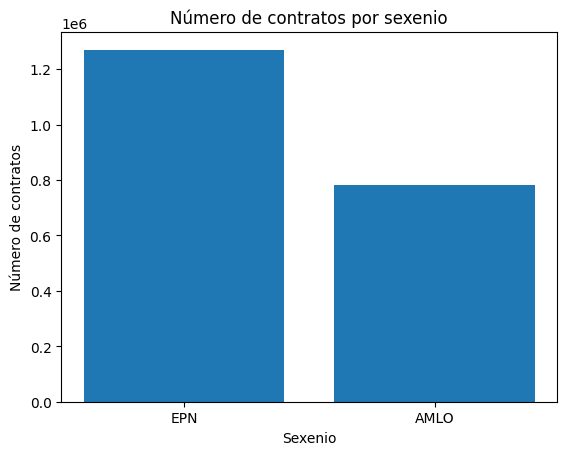

In [53]:
import matplotlib.pyplot as plt

contratos_pd = contratos_sexenio.toPandas()

plt.figure()
plt.bar(contratos_pd["sexenio"], contratos_pd["count"])
plt.xlabel("Sexenio")
plt.ylabel("Número de contratos")
plt.title("Número de contratos por sexenio")
plt.show()


### Monto total por sexenio

In [54]:
from pyspark.sql.functions import sum

monto_sexenio = df.groupBy("sexenio").agg(
    sum("importe_real").alias("monto_total")
)

monto_sexenio.show()

+-------+--------------------+
|sexenio|         monto_total|
+-------+--------------------+
|    EPN|3.222897523224105E12|
|   AMLO|1.938538504416509...|
+-------+--------------------+



  sexenio   monto_total
0     EPN  3.222898e+12
1    AMLO  1.938539e+12


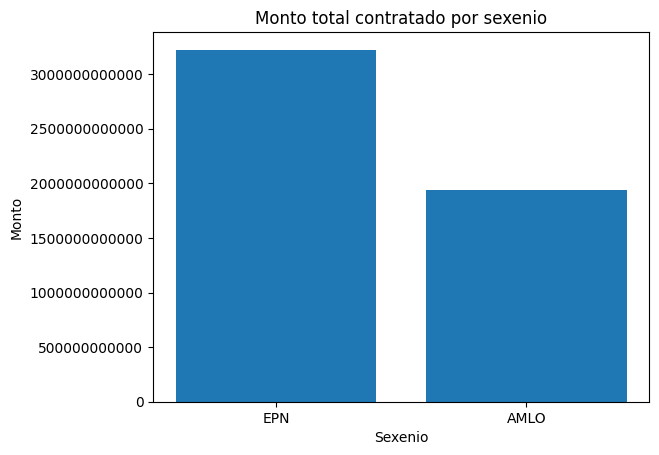

In [55]:
monto_pd = monto_sexenio.toPandas()

print(monto_pd)

import matplotlib.pyplot as plt

plt.figure()

plt.bar(monto_pd["sexenio"], monto_pd["monto_total"])

plt.title("Monto total contratado por sexenio")
plt.xlabel("Sexenio")
plt.ylabel("Monto")

plt.ticklabel_format(style='plain', axis='y')

plt.show()

### Modalidades de contratación

In [56]:
from pyspark.sql.functions import when, col

df = df.withColumn(
    "tipo_procedimiento",
    when(col("tipo_expediente").like("%Adjudicación Directa%"), "ADJUDICACION_DIRECTA")
    .when(col("tipo_expediente").like("%Invitación%"), "INVITACION_3")
    .when(col("tipo_expediente").like("%Licitación Pública%"), "LICITACION_PUBLICA")
    .otherwise("OTROS")
)

In [57]:
df.select("tipo_expediente","tipo_procedimiento").show(20, truncate=False)

+------------------------------------------------------------------------+--------------------+
|tipo_expediente                                                         |tipo_procedimiento  |
+------------------------------------------------------------------------+--------------------+
|05. Adjudicación Directa LAASSP                                         |ADJUDICACION_DIRECTA|
|05. Adjudicación Directa LAASSP                                         |ADJUDICACION_DIRECTA|
|05. Adjudicación Directa LAASSP                                         |ADJUDICACION_DIRECTA|
|05. Adjudicación Directa LAASSP                                         |ADJUDICACION_DIRECTA|
|05. Adjudicación Directa LAASSP                                         |ADJUDICACION_DIRECTA|
|05. Adjudicación Directa LAASSP                                         |ADJUDICACION_DIRECTA|
|05. Adjudicación Directa LAASSP                                         |ADJUDICACION_DIRECTA|
|08. Reporte de otras contrataciones y c

In [58]:
modalidades = df.groupBy(
    "sexenio",
    "tipo_procedimiento"
).count()

In [59]:
modalidades_pd = modalidades.toPandas()

print(modalidades_pd.columns)

Index(['sexenio', 'tipo_procedimiento', 'count'], dtype='object')


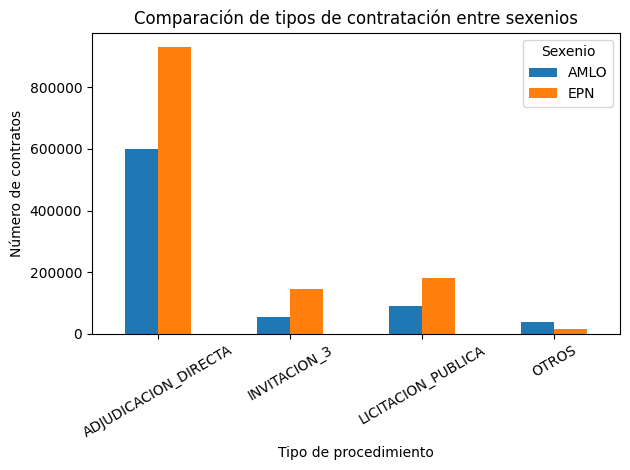

In [60]:
pivot = modalidades_pd.pivot(
    index="tipo_procedimiento",
    columns="sexenio",
    values="count"
)

pivot.plot(kind="bar")

import matplotlib.pyplot as plt

plt.title("Comparación de tipos de contratación entre sexenios")
plt.xlabel("Tipo de procedimiento")
plt.ylabel("Número de contratos")

plt.xticks(rotation=30)
plt.legend(title="Sexenio")

plt.tight_layout()
plt.show()

### Evolución temporal

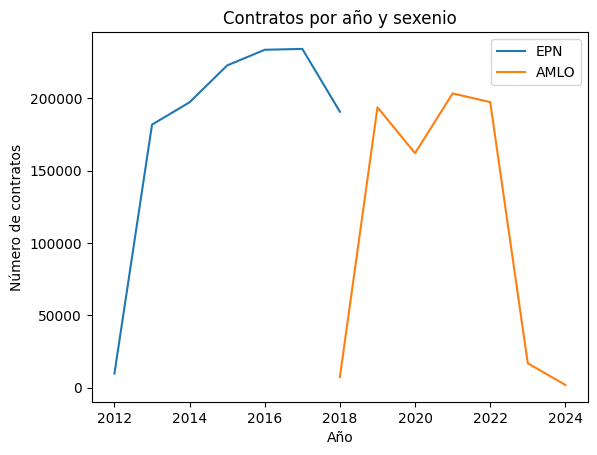

In [61]:
contratos_anio_pd = contrato_anio.toPandas()

plt.figure()
for s in contratos_anio_pd["sexenio"].unique():
  subset = contratos_anio_pd[contratos_anio_pd["sexenio"] == s]
  plt.plot(subset["anio"], subset["count"], label=s)

plt.legend()
plt.title("Contratos por año y sexenio")
plt.xlabel("Año")
plt.ylabel("Número de contratos")
plt.show()

## Modelos Logit

### Creación var binaria

In [62]:
from pyspark.sql.functions import when

df_logit = df.withColumn(
    "adjudicacion",
    when(col("tipo_expediente").like("%Adjudicación Directa%"), 1)
    .otherwise(0)
)


In [63]:
pdf = df_logit.select(
    "adjudicacion",
    "importe",
    "duración_días",
    "anio"
).dropna().toPandas()

In [64]:
import statsmodels.api as sm

X = pdf[["importe", "duración_días", "anio"]]
y = pdf["adjudicacion"]

X = sm.add_constant(X)

logit_model = sm.Logit(y, X).fit()

print(logit_model.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


Optimization terminated successfully.
         Current function value: inf
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:           adjudicacion   No. Observations:              2052702
Model:                          Logit   Df Residuals:                  2052698
Method:                           MLE   Df Model:                            3
Date:                Sat, 21 Mar 2026   Pseudo R-squ.:                    -inf
Time:                        00:03:24   Log-Likelihood:                   -inf
converged:                       True   LL-Null:                   -1.1637e+06
Covariance Type:            nonrobust   LLR p-value:                     1.000
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const          -103.9696      1.183    -87.876      0.000    -106.288    -101.651
importe       -1.743e-08 

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


## Redes de proveedores

### Tabla de relaciones

In [65]:
from pyspark.sql.functions import count

red = df.groupBy(
    "proveedor",
    "tipo_expediente"
).agg(
    count("*").alias("conteo")
)

In [66]:
red_filtrada = red.filter(col("conteo") > 50)

### Top Proveedores

In [67]:
from pyspark.sql.functions import sum

top_proveedores = df.groupBy("proveedor").agg(
    sum("importe_real").alias("monto_total")
).orderBy(col("monto_total").desc()).limit(50)

In [68]:
red_final = red_filtrada.join(
    top_proveedores.select("proveedor"),
    "proveedor"
)

### Convertir a Pandas

In [69]:
red_pd = red_final.toPandas()

### Creación de grafo

In [70]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

for _, row in red_pd.iterrows():
    G.add_edge(
        row["proveedor"],
        row["tipo_expediente"],
        weight=row["conteo"]
    )

### Grafo

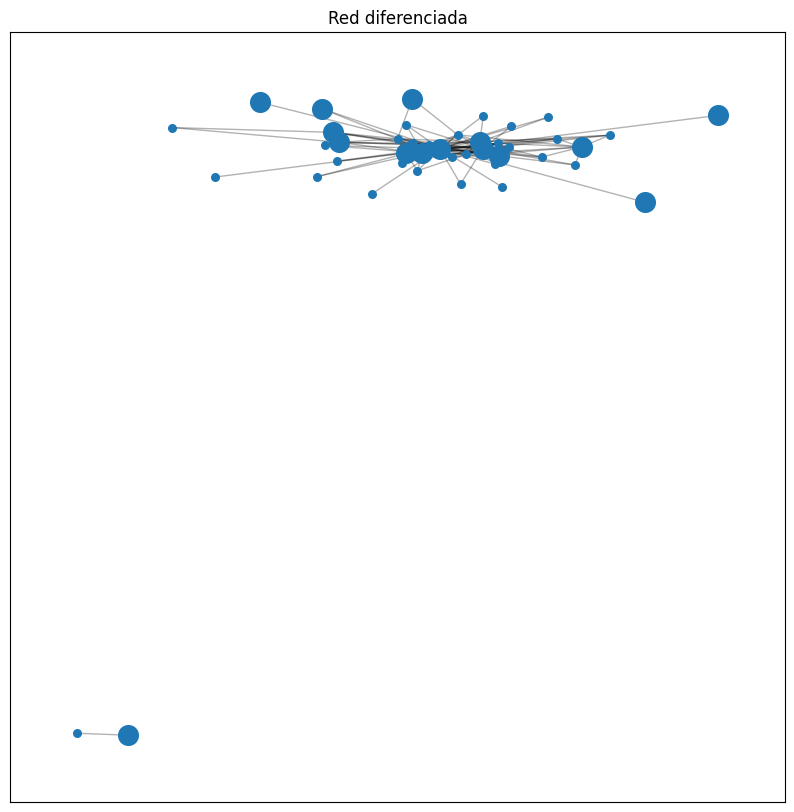

In [71]:
proveedores = [n for n in G.nodes if n in red_pd["proveedor"].values]
tipos = [n for n in G.nodes if n not in proveedores]

plt.figure(figsize=(10,10))

pos = nx.spring_layout(G)

nx.draw_networkx_nodes(G, pos, nodelist=proveedores, node_size=30)
nx.draw_networkx_nodes(G, pos, nodelist=tipos, node_size=200)

nx.draw_networkx_edges(G, pos, alpha=0.3)

plt.title("Red diferenciada")
plt.show()

## Análisis de tendencia temporal

### Serie de tiempo

In [72]:
ts = df.groupBy(
    "anio",
    "sexenio"
).agg(
    sum("importe_real").alias("monto_total")
).orderBy("anio")

ts_pd = ts.toPandas()

### Regresión temporal

In [73]:
import numpy as np
from sklearn.linear_model import LinearRegression

for s in ts_pd["sexenio"].unique():
    subset = ts_pd[ts_pd["sexenio"] == s]

    X = subset["anio"].values.reshape(-1,1)
    y = subset["monto_total"].values

    model = LinearRegression()
    model.fit(X,y)

    print(f"Tendencia {s}:", model.coef_[0])

Tendencia EPN: 46793140496.444885
Tendencia AMLO: -13752538264.104597
